# MTS dimensionality preview

Preview the MTS heatmaps and channel-space intrinsic dimensionality that a given experiment YAML would produce, **without running pyspi or writing anything to disk**. Use this to tune generator parameters before committing a large cluster run.

**Filter rationale** (see Cliff et al., *Unifying pairwise interactions in complex dynamics*, Nat. Comput. Sci. 2023): when the feature is `corr(MPI_i-offdiag, MPI_j-offdiag)`, the effective sample size of that correlation is bounded by the channel intrinsic dimension `d` via `d(d−1)/2` independent pairs — **not** by the nominal `M(M−1)/2`. Systems with `d < 3` cannot support a meaningful correlation estimate regardless of `M`. The filter is `n_pcs_at_alpha ≥ n_pcs_min` with defaults `alpha=0.95`, `n_pcs_min=3`.

PCA is on z-scored channels (correlation-matrix PCA) to match what most SPIs see and to avoid collapse on heavy-tailed classes.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.mapping import ExperimentConfig, DatasetMapping
from src.run_experiments import generate_synthetic_from_spec, build_mts_heatmap
from src.dimensionality import n_pcs_for_variance, explained_variance_curve

## 1. Load config

Change `CONFIG_PATH` to point at any experiment YAML. Synthetic classes are supported; real/yfinance classes are skipped (they don't have generator params to sweep).

In [2]:
CONFIG_PATH = PROJECT_ROOT / "configs/generate/embeddings/proof.yaml"

config = ExperimentConfig.from_file(CONFIG_PATH)
config.timestamp = False  # deterministic spec.dataset_dir; no disk writes in this notebook regardless
mapping = DatasetMapping(config)

summary = pd.DataFrame(mapping.summaries())
print(f"Loaded {len(mapping)} specs from {CONFIG_PATH.relative_to(PROJECT_ROOT)}")
print(f"Classes: {sorted(summary['class'].unique().tolist())}")
summary.head()

Loaded 1260 specs from configs/generate/embeddings/proof.yaml
Classes: ['brownian-defect', 'cauchy-noise', 'chaotic-traveling-wave', 'defect-turbulence', 'fdstc', 'frozen-chaos', 'gaussian-noise', 'kuramoto', 'pattern-selection', 'sti-i', 'sti-ii', 'traveling-wave', 'traveling-wave-kaneko67', 'var-ring-sym']


,index,class,variant,M,T,instance,pyspi_config,dataset_dir
0,1,var-ring-sym,,5,500,0,/Users/wedi0306/Code/mts-spi-study-cluster/con...,/Users/wedi0306/Code/mts-spi-study-cluster/dat...
1,2,var-ring-sym,,5,500,1,/Users/wedi0306/Code/mts-spi-study-cluster/con...,/Users/wedi0306/Code/mts-spi-study-cluster/dat...
2,3,var-ring-sym,,5,500,2,/Users/wedi0306/Code/mts-spi-study-cluster/con...,/Users/wedi0306/Code/mts-spi-study-cluster/dat...
3,4,var-ring-sym,,5,500,3,/Users/wedi0306/Code/mts-spi-study-cluster/con...,/Users/wedi0306/Code/mts-spi-study-cluster/dat...
4,5,var-ring-sym,,5,500,4,/Users/wedi0306/Code/mts-spi-study-cluster/con...,/Users/wedi0306/Code/mts-spi-study-cluster/dat...


## 2. Select scope

Pick one: a class name (or list), specific spec indices, specific `M` values, or all. Set to `None` to not filter on that axis.

In [3]:
CLASS_FILTER: str | list[str] | None = "kuramoto"   # e.g. "kuramoto", ["kuramoto", "frozen-chaos"], or None
INDEX_FILTER: list[int] | None = None                # e.g. [1, 5, 10]
M_FILTER: list[int] | None = None                    # e.g. [5, 10]
T_FILTER: list[int] | None = None                    # e.g. [1000]
INSTANCE_FILTER: list[int] | None = None             # e.g. [0, 1, 2]

def select_specs(mapping, *, class_filter=None, index_filter=None, m_filter=None, t_filter=None, instance_filter=None):
    classes = (
        None if class_filter is None
        else ([class_filter] if isinstance(class_filter, str) else list(class_filter))
    )
    out = []
    for spec in mapping.specs:
        if spec.source != "synthetic":
            continue
        if classes is not None and spec.mts_class not in classes:
            continue
        if m_filter is not None and spec.M not in m_filter:
            continue
        if t_filter is not None and spec.T not in t_filter:
            continue
        if instance_filter is not None and spec.instance not in instance_filter:
            continue
        if index_filter is not None and spec.index not in index_filter:
            continue
        out.append(spec)
    return out

specs = select_specs(
    mapping,
    class_filter=CLASS_FILTER,
    index_filter=INDEX_FILTER,
    m_filter=M_FILTER,
    t_filter=T_FILTER,
    instance_filter=INSTANCE_FILTER,
)
print(f"Selected {len(specs)} specs")

Selected 90 specs


## 3. Generate (in memory)

Optional `PARAM_OVERRIDES` patches `generator_params` on the selected specs non-destructively (mutates the in-memory `DatasetSpec` objects; re-run cell 1 to reset from YAML). The generation is deterministic per `(class, M, T, I, params)` via `spec.rng_seed`, so re-running this cell with the same overrides produces identical data.

In [4]:
PARAM_OVERRIDES: dict = {
    # Examples:
    # "K": -2.0,          # Kuramoto coupling (more negative = stronger anti-phase push)
    # "alpha": 1.75,      # CML control param (per-regime)
    # "eps": 0.1,         # CML diffusive coupling
    # "noise_std": 0.05,
}

records = []
generated: dict[int, np.ndarray] = {}  # spec.index -> data
for spec in specs:
    patched = dict(spec.generator_params)
    patched.update(PARAM_OVERRIDES)
    spec.generator_params = patched
    data, _ = generate_synthetic_from_spec(spec)
    generated[spec.index] = data
    records.append({
        "index": spec.index,
        "class": spec.mts_class,
        "M": spec.M,
        "T": spec.T,
        "I": spec.instance,
    })

df = pd.DataFrame(records)
print(f"Generated {len(df)} timeseries in memory.")
df.head()

Generated 90 timeseries in memory.


,index,class,M,T,I
0,91,kuramoto,5,500,0
1,92,kuramoto,5,500,1
2,93,kuramoto,5,500,2
3,94,kuramoto,5,500,3
4,95,kuramoto,5,500,4


## 4. Dimensionality filter

`ALPHA` = variance threshold, `N_PCS_MIN` = minimum passing dimensionality. A dataset **passes** when `n_pcs_at_alpha ≥ N_PCS_MIN`. Re-run this cell alone to retune the knobs without regenerating.

In [5]:
ALPHA = 0.95
N_PCS_MIN = 3

df["n_pcs"] = [n_pcs_for_variance(generated[i], alpha=ALPHA) for i in df["index"]]
df["n_pcs/M"] = (df["n_pcs"] / df["M"]).round(3)
df["pass"] = df["n_pcs"] >= N_PCS_MIN

print(f"Filter: alpha={ALPHA}, n_pcs_min={N_PCS_MIN}")
print(f"Pass rate overall: {df['pass'].mean():.1%}  ({df['pass'].sum()}/{len(df)})")

per_group = df.groupby(["class", "M", "T"]).agg(
    n=("index", "count"),
    pass_rate=("pass", "mean"),
    median_n_pcs=("n_pcs", "median"),
    min_n_pcs=("n_pcs", "min"),
    max_n_pcs=("n_pcs", "max"),
)
display(per_group)

Filter: alpha=0.95, n_pcs_min=3
Pass rate overall: 100.0%  (90/90)


n  pass_rate  median_n_pcs  min_n_pcs  max_n_pcs
class    M  T                                                      
kuramoto 5  500   10        1.0           4.0          3          5
            1000  10        1.0           4.0          3          5
            2000  10        1.0           4.0          3          5
         10 500   10        1.0           7.0          6         10
            1000  10        1.0           8.0          7         10
            2000  10        1.0           7.5          6          9
         20 500   10        1.0          15.0         13         16
            1000  10        1.0          15.0         13         18
            2000  10        1.0          15.0         13         18

## 5. Dimensionality distribution (per class × M)

Boxplot of `n_pcs` across instances. Red dashed line = `N_PCS_MIN`. Use this to judge whether a class is *reliably* high-dim across seeds, or if low-dim realizations are a minority you can live with.

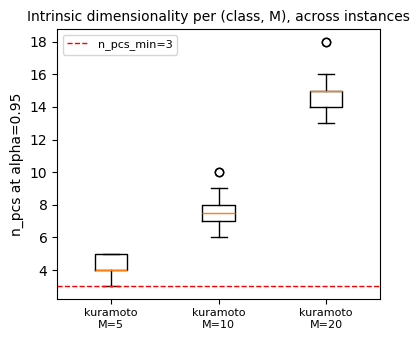

In [6]:
groups = list(df.groupby(["class", "M"]))
if groups:
    fig, ax = plt.subplots(figsize=(max(4, 0.6 * len(groups)), 3.5))
    labels, values = [], []
    for (cls, M), sub in groups:
        labels.append(f"{cls}\nM={M}")
        values.append(sub["n_pcs"].values)
    ax.boxplot(values, positions=range(len(groups)))
    ax.axhline(N_PCS_MIN, color="red", linestyle="--", linewidth=1, label=f"n_pcs_min={N_PCS_MIN}")
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel(f"n_pcs at alpha={ALPHA}")
    ax.set_title("Intrinsic dimensionality per (class, M), across instances", fontsize=10)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. Heatmap preview

`PREVIEW` selects which realizations to visualize: `"pass"`, `"fail"`, `"all"`, or a list of `index` values from `df`. `MAX_PREVIEW` caps the count.

In [7]:
PREVIEW: str | list[int] = "fail"
MAX_PREVIEW = 8

def _preview_subset(df, kind):
    if isinstance(kind, list):
        return df[df["index"].isin(kind)]
    if kind == "all":
        return df
    if kind == "pass":
        return df[df["pass"]]
    if kind == "fail":
        return df[~df["pass"]]
    raise ValueError(f"Unknown PREVIEW: {kind}")

preview_df = _preview_subset(df, PREVIEW).head(MAX_PREVIEW)
print(f"Previewing {len(preview_df)} of {len(df)} (PREVIEW={PREVIEW!r})")

for _, row in preview_df.iterrows():
    data = generated[row["index"]]
    verdict = "PASS" if row["pass"] else "FAIL"
    print(f"idx={row['index']}  {row['class']}  M={row['M']} T={row['T']} I={row['I']}  n_pcs={row['n_pcs']}  {verdict}")
    fig = build_mts_heatmap(data)
    plt.show()
    plt.close(fig)

Previewing 0 of 90 (PREVIEW='fail')


## 8. Worked example — Kuramoto K sweep

Kuramoto at `K=-4` in [proof.yaml](../../configs/generate/embeddings/proof.yaml) tends to be low-dim at small `M`. Sweep `K` across a range at each `M` in the config grid to find a regime where most instances pass the filter. This is the **parameter-choice** problem — do it here, before the cluster run, rather than rejection-sampling seeds later.

Only a few instances per (K, M) are run here to keep it fast; bump `INSTANCE_CAP` for a more robust picture.

In [8]:
K_SWEEP = [-8.0, -4.0, -2.0, -1.0, 0.0, 1.0, 2.0, 4.0, 8.0]
T_FOR_SWEEP = 1000
INSTANCE_CAP = 3

kura_base = [
    s for s in mapping.specs
    if s.mts_class == "kuramoto" and s.T == T_FOR_SWEEP and s.instance < INSTANCE_CAP
]
print(f"Sweeping K={K_SWEEP} across {len(kura_base)} base specs (M×I) at T={T_FOR_SWEEP}")

sweep_records = []
sweep_data: dict[tuple[float, int, int], np.ndarray] = {}
for spec in kura_base:
    for K in K_SWEEP:
        patched = dict(spec.generator_params)
        patched["K"] = K
        spec.generator_params = patched
        data, _ = generate_synthetic_from_spec(spec)
        d = n_pcs_for_variance(data, alpha=ALPHA)
        sweep_data[(K, spec.M, spec.instance)] = data
        sweep_records.append({
            "K": K, "M": spec.M, "I": spec.instance,
            "n_pcs": d, "pass": d >= N_PCS_MIN,
        })

sweep_df = pd.DataFrame(sweep_records)
print(f"Generated {len(sweep_df)} sweep points.")

Sweeping K=[-8.0, -4.0, -2.0, -1.0, 0.0, 1.0, 2.0, 4.0, 8.0] across 9 base specs (M×I) at T=1000
Generated 81 sweep points.


In [9]:
print("Median n_pcs per (K, M):")
display(sweep_df.pivot_table(index="K", columns="M", values="n_pcs", aggfunc="median"))

print(f"\nPass rate per (K, M) at n_pcs_min={N_PCS_MIN}:")
display(sweep_df.pivot_table(index="K", columns="M", values="pass", aggfunc="mean"))

Median n_pcs per (K, M):


M,5,10,20
K,,,
-8.0,2.0,2.0,3.0
-4.0,3.0,4.0,6.0
-2.0,3.0,6.0,11.0
-1.0,4.0,8.0,15.0
0.0,5.0,9.0,17.0
1.0,4.0,8.0,14.0
2.0,3.0,6.0,11.0
4.0,2.0,4.0,6.0
8.0,2.0,2.0,3.0



Pass rate per (K, M) at n_pcs_min=3:


M,5,10,20
K,,,
-8.0,0.000000,0.000000,0.666667
-4.0,0.666667,0.666667,1.000000
-2.0,0.666667,1.000000,1.000000
-1.0,1.000000,1.000000,1.000000
0.0,1.000000,1.000000,1.000000
1.0,1.000000,1.000000,1.000000
2.0,0.666667,1.000000,1.000000
4.0,0.000000,0.666667,1.000000
8.0,0.000000,0.000000,0.666667


K=-8.0  M=10  I=0  n_pcs=2  FAIL


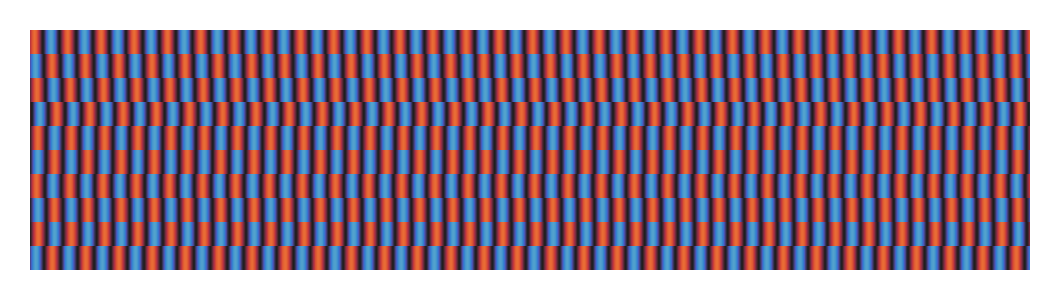

K=-4.0  M=10  I=0  n_pcs=4  PASS


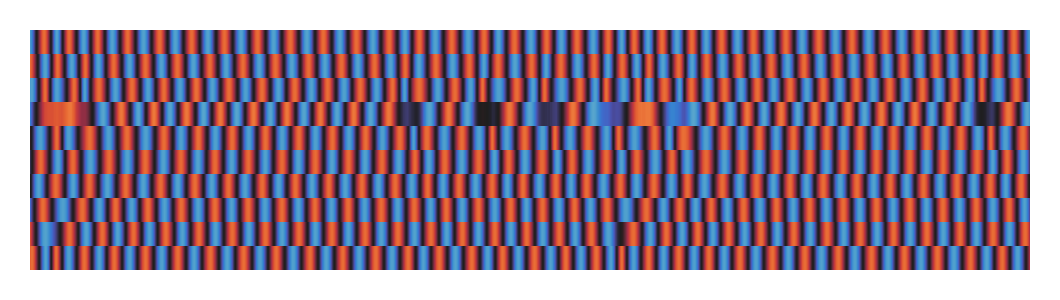

K=-2.0  M=10  I=0  n_pcs=6  PASS


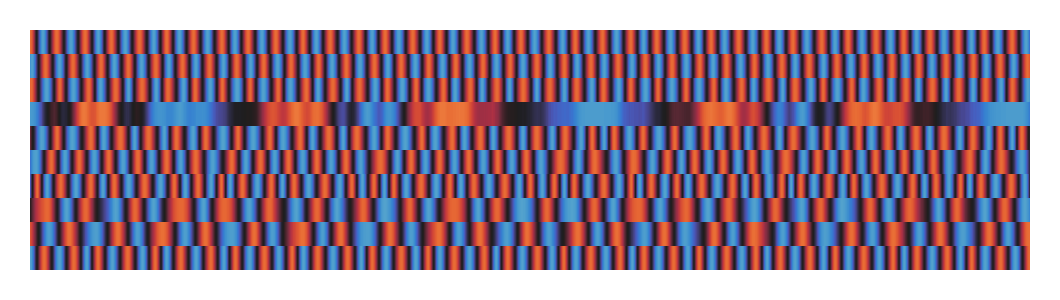

K=-1.0  M=10  I=0  n_pcs=8  PASS


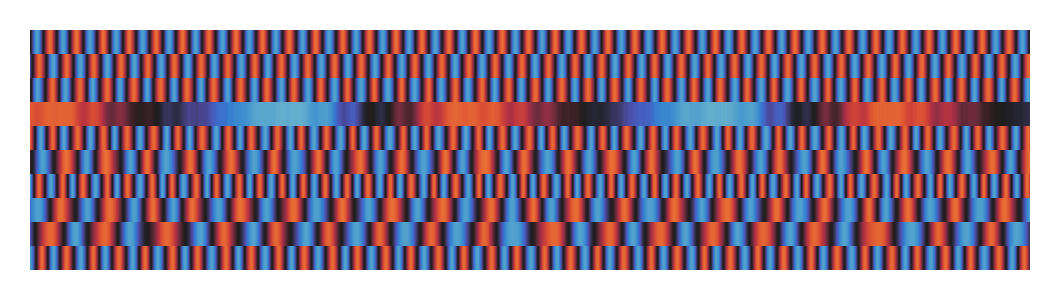

K=0.0  M=10  I=0  n_pcs=10  PASS


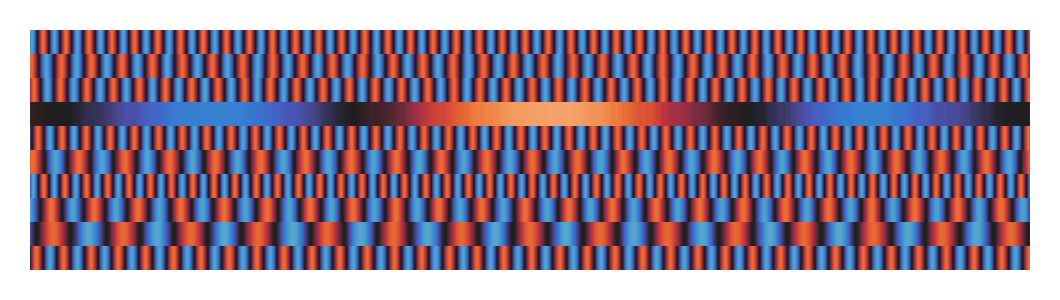

K=1.0  M=10  I=0  n_pcs=8  PASS


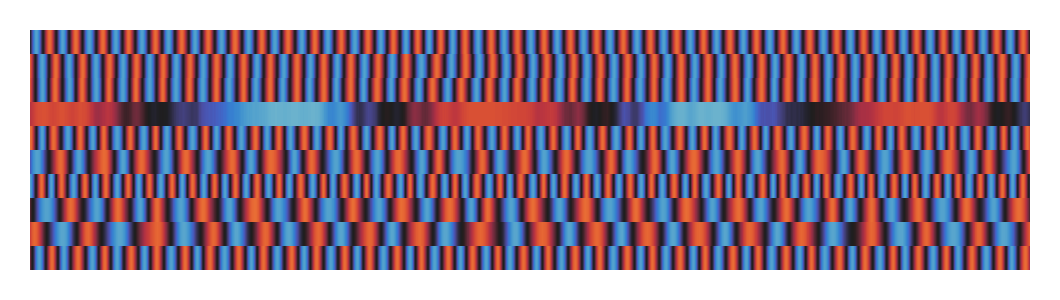

K=2.0  M=10  I=0  n_pcs=6  PASS


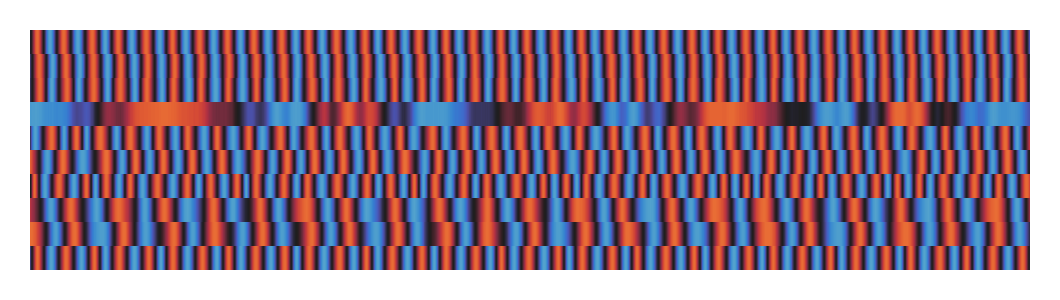

K=4.0  M=10  I=0  n_pcs=4  PASS


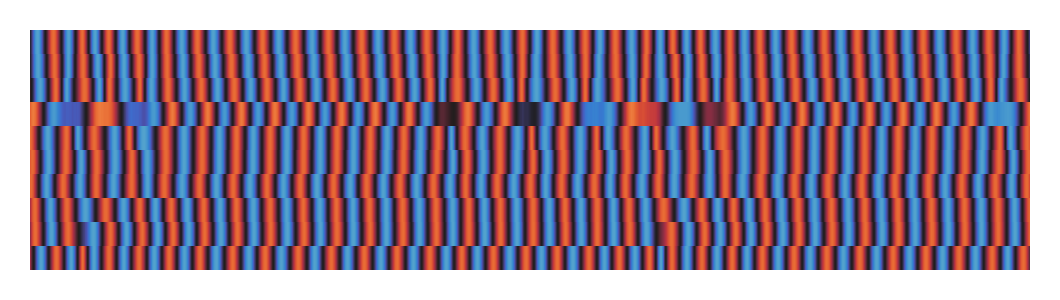

K=8.0  M=10  I=0  n_pcs=2  FAIL


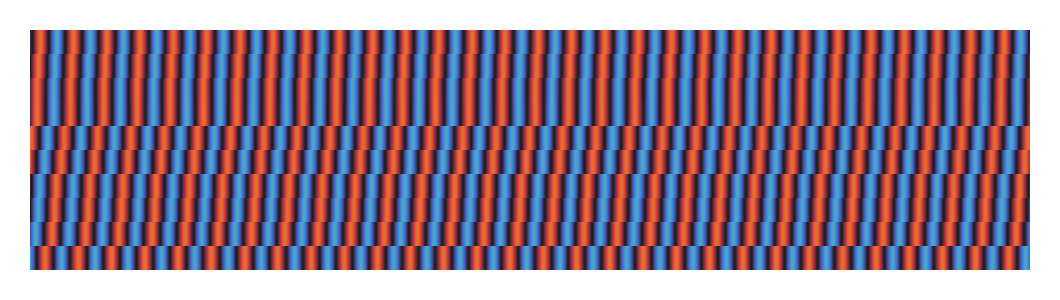

In [10]:
# Heatmap strip across K at a chosen M (instance 0)
M_HEATMAP = 10
I_HEATMAP = 0

for K in K_SWEEP:
    key = (K, M_HEATMAP, I_HEATMAP)
    if key not in sweep_data:
        continue
    row = sweep_df[(sweep_df["K"] == K) & (sweep_df["M"] == M_HEATMAP) & (sweep_df["I"] == I_HEATMAP)].iloc[0]
    verdict = "PASS" if row["pass"] else "FAIL"
    print(f"K={K}  M={M_HEATMAP}  I={I_HEATMAP}  n_pcs={row['n_pcs']}  {verdict}")
    fig = build_mts_heatmap(sweep_data[key])
    plt.show()
    plt.close(fig)